# 03 - Modeling Baseline: Logistic Regression + WOE Binning

Tujuan notebook ini:
1. Membangun model baseline dengan pendekatan **scorecard klasik** industri perbankan:
   Weight of Evidence (WOE) binning + Logistic Regression
2. Pendekatan ini dipilih sebagai baseline (bukan random/dummy classifier) karena
   ini adalah standar industri yang regulatory-friendly — model yang
   hasilnya dipakai untuk dibandingkan dengan model yang lebih kompleks (LightGBM)
   di notebook selanjutnya
3. Mencatat AUC, Gini, KS sebagai skor pembanding

**Kenapa WOE + Logistic Regression dipakai sebagai baseline, bukan dianggap
"kuno"?** Di industri credit scoring riil, model ini masih dipakai luas karena:
- Setiap variabel punya bobot yang bisa dijelaskan langsung ke risk committee/regulator (OJK)
- Monotonic by design (tidak ada hubungan non-linear yang aneh/sulit dijelaskan)
- Mudah diaudit dan stabil dari waktu ke waktu


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from src.config import TARGET_COL, ID_COL, PROCESSED_DATA_DIR, RANDOM_SEED, TEST_SIZE
from src.evaluation import evaluation_summary, ks_statistic

sns.set_style("whitegrid")


## 1. Load Master Table

In [2]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "master_table.parquet")
print(f"Shape: {df.shape}")

# Pisahkan fitur numerik untuk WOE binning (kategorikal ditangani terpisah
# kalau diperlukan -- untuk versi awal ini fokus ke numerik dulu)
feature_cols = [
    c for c in df.columns
    if c not in [ID_COL, TARGET_COL] and pd.api.types.is_numeric_dtype(df[c])
]
print(f"Jumlah fitur numerik kandidat: {len(feature_cols)}")


Shape: (307511, 137)
Jumlah fitur numerik kandidat: 119


In [3]:
X = df[feature_cols]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate train: {y_train.mean():.4f}, test: {y_test.mean():.4f}")

Train: (246008, 119), Test: (61503, 119)
Default rate train: 0.0807, test: 0.0807


## 2. WOE Binning

Menggunakan `optbinning` untuk binning otomatis yang menjaga monotonicity
(syarat penting di scorecard industri -- WOE harus naik/turun secara
konsisten sepanjang bin, tidak boleh naik-turun acak karena akan sulit
dijelaskan secara bisnis).

In [4]:
from optbinning import BinningProcess

In [5]:
# Pilih subset fitur dengan missing rate rendah dulu untuk binning awal
# (fitur dengan missing tinggi akan butuh penanganan khusus, bisa
# dieksplorasi di iterasi berikutnya)
missing_rate = X_train.isnull().mean()
candidate_features = missing_rate[missing_rate < 0.3].index.tolist()
print(f"Fitur kandidat untuk WOE binning (missing < 30%): {len(candidate_features)}")

binning_process = BinningProcess(variable_names=candidate_features)
binning_process.fit(X_train[candidate_features].values, y_train.values)


Fitur kandidat untuk WOE binning (missing < 30%): 74


,variable_names,"['CNT_CHILDREN', 'AMT_INCOME_TOTAL', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,None
,fixed_variables,None


In [ ]:
# Transform ke WOE values
X_train_woe = binning_process.transform(X_train[candidate_features].values, metric="woe")
X_test_woe = binning_process.transform(X_test[candidate_features].values, metric="woe")

X_train_woe = pd.DataFrame(X_train_woe, columns=candidate_features, index=X_train.index)
X_test_woe = pd.DataFrame(X_test_woe, columns=candidate_features, index=X_test.index)

print("Contoh hasil WOE transform:")
X_train_woe.head()

Contoh hasil WOE transform:


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,prev_application_count,prev_amt_credit_mean,prev_amt_annuity_mean,prev_days_decision_mean,DEBT_TO_INCOME_RATIO,ANNUITY_TO_INCOME_RATIO,CREDIT_TO_ANNUITY_RATIO,AGE_YEARS,EMPLOYMENT_TO_AGE_RATIO,BUREAU_CREDIT_TO_INCOME_RATIO
181648,-0.107260,-0.045581,0.041078,0.173267,-0.017004,-0.045439,-0.235756,-0.343461,0.066914,0.299530,...,0.018002,0.011040,-0.019988,0.309713,-0.094083,0.038546,-0.049984,-0.235756,-0.257584,0.044764
229245,0.053457,-0.045581,0.041078,0.173267,0.241728,-0.045439,0.038379,-0.309683,-0.081007,-0.095481,...,0.007407,-0.003542,-0.019988,-0.345095,0.014621,0.038546,-0.049984,0.038379,-0.323904,0.000000
122525,0.053457,-0.053162,0.075179,-0.127729,0.047079,-0.305811,0.166426,-0.129718,0.139380,-0.077276,...,-0.025633,-0.117751,-0.019988,0.153466,0.066567,-0.061920,-0.049984,0.166426,-0.206995,0.044764
306311,0.053457,-0.053162,-0.215214,-0.051143,-0.277786,-0.045439,0.137161,-0.129718,-0.081007,-0.185116,...,-0.022768,-0.000258,-0.019988,0.309713,-0.122699,-0.107294,-0.049984,0.137161,-0.206995,0.044764
300658,0.053457,-0.039964,0.041078,-0.127729,-0.043876,-0.045439,-0.446316,-0.258286,-0.081007,-0.223162,...,0.029108,-0.333017,-0.317842,-0.165214,0.068235,0.038546,0.537187,-0.446316,-0.075048,0.000000


## 3. Cek Information Value per Fitur (dari hasil binning)

`optbinning` otomatis menghitung IV per fitur -- ini dipakai untuk seleksi
fitur sebelum masuk ke model final (fitur dengan IV terlalu rendah
dibuang, fitur dengan IV mencurigakan tinggi dicek potensi leakage).

**Catatan:** angka IV di sini kemungkinan sedikit berbeda dari hasil
`calculate_iv()` manual di notebook 02 -- itu wajar, karena `optbinning`
menggunakan algoritma binning optimal (mempertimbangkan monotonicity),
sedangkan fungsi manual sebelumnya hanya memakai quantile binning
sederhana. Perbedaan metodologi binning, bukan kesalahan perhitungan.

In [7]:
iv_summary = binning_process.summary()
iv_summary_sorted = iv_summary.sort_values("iv", ascending=False)
iv_summary_sorted[["name", "iv", "gini", "quality_score"]].head(20)

,name,iv,gini,quality_score
27,EXT_SOURCE_3,0.335337,0.316371,0.517872
26,EXT_SOURCE_2,0.319012,0.309656,0.26746
7,DAYS_EMPLOYED,0.115802,0.189959,0.430119
4,AMT_GOODS_PRICE,0.092476,0.163452,0.214146
72,EMPLOYMENT_TO_AGE_RATIO,0.091639,0.167409,0.120828
6,DAYS_BIRTH,0.090281,0.169374,0.060788
71,AGE_YEARS,0.090281,0.169374,0.060788
2,AMT_CREDIT,0.05917,0.132396,0.225969
18,REGION_RATING_CLIENT_W_CITY,0.051572,0.098996,0.109243
17,REGION_RATING_CLIENT,0.048177,0.096205,0.104419


**Insight:** *(isi setelah melihat tabel IV -- fitur mana yang paling kuat
secara univariate, apakah ada yang IV-nya di atas 0.5 yang perlu dicurigai
sebagai potential leakage)*

## 4. Training Logistic Regression

In [8]:
# Seleksi fitur dengan IV memadai (>= 0.02, sesuai rule of thumb industri)
selected_features = iv_summary_sorted[iv_summary_sorted["iv"] >= 0.02]["name"].tolist()
print(f"Fitur terpilih (IV >= 0.02): {len(selected_features)}")

X_train_final = X_train_woe[selected_features].fillna(0)
X_test_final = X_test_woe[selected_features].fillna(0)

lr_model = LogisticRegression(
    class_weight="balanced",  # penting karena target imbalanced
    random_state=RANDOM_SEED,
    max_iter=1000,
)
lr_model.fit(X_train_final, y_train)

y_pred_proba_train = lr_model.predict_proba(X_train_final)[:, 1]
y_pred_proba_test = lr_model.predict_proba(X_test_final)[:, 1]


Fitur terpilih (IV >= 0.02): 24


## 5. Evaluasi Baseline

In [9]:
print("=== Train ===")
print(evaluation_summary(y_train, y_pred_proba_train))
print("\n=== Test ===")
print(evaluation_summary(y_test, y_pred_proba_test))

=== Train ===
AUC      0.7347
Gini     0.4693
KS      35.0100
dtype: float64

=== Test ===
AUC      0.7364
Gini     0.4728
KS      35.1000
dtype: float64


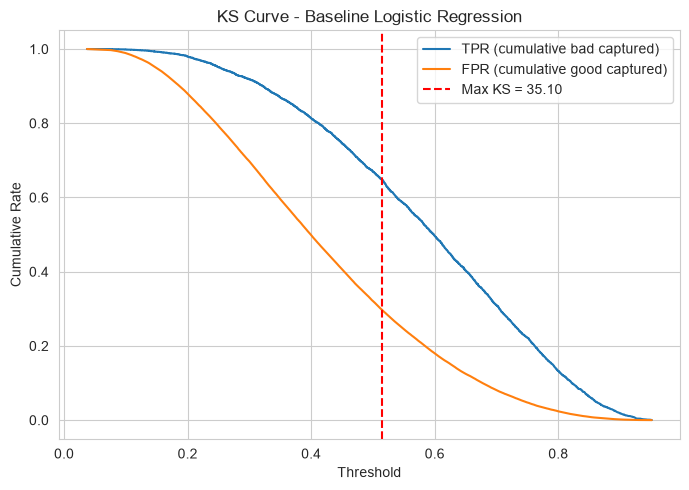

In [ ]:
ks_value, ks_curve = ks_statistic(y_test, y_pred_proba_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ks_curve["threshold"], ks_curve["tpr"], label="TPR (cumulative bad captured)")
ax.plot(ks_curve["threshold"], ks_curve["fpr"], label="FPR (cumulative good captured)")
ax.axvline(
    ks_curve.loc[ks_curve["ks"].idxmax(), "threshold"],
    color="red", linestyle="--", label=f"Max KS = {ks_value:.2f}"
)
ax.set_xlabel("Threshold")
ax.set_ylabel("Cumulative Rate")
ax.set_title("KS Curve - Baseline Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Koefisien Model (Interpretasi Bisnis)

Karena fitur sudah dalam bentuk WOE, koefisien positif berarti fitur
tersebut berkontribusi menurunkan risiko (semakin tinggi WOE → semakin
banyak nasabah baik di bin tersebut), dan sebaliknya.

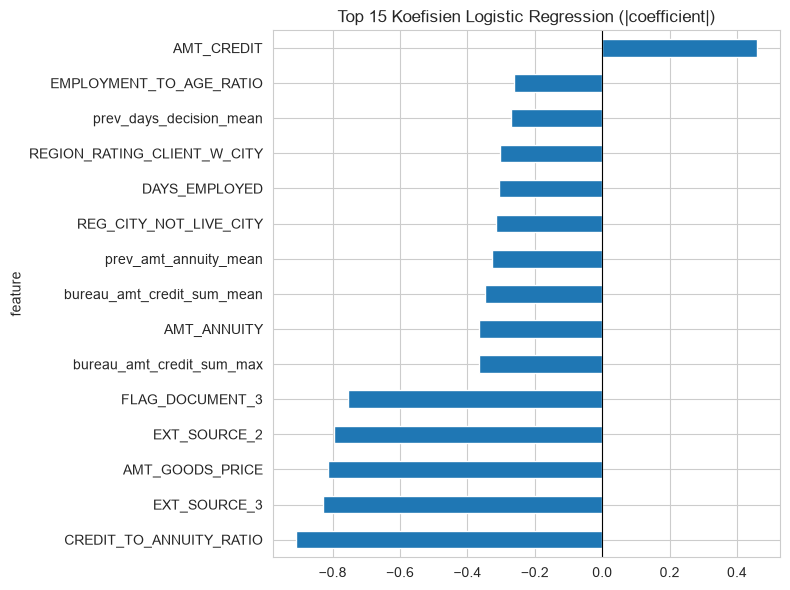

In [ ]:
coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": lr_model.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
coef_df.head(15).set_index("feature")["coefficient"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 Koefisien Logistic Regression (|coefficient|)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Ringkasan

*(isi: skor AUC/Gini/KS baseline ini akan jadi pembanding untuk model
LightGBM di notebook `04_modeling_gbm.ipynb`. Catat juga fitur mana yang
paling berpengaruh menurut model linear ini, untuk dibandingkan nanti
dengan hasil SHAP dari model GBM.)*

Lanjut ke `04_modeling_gbm.ipynb`.